# Chapter 04: Spaces of Bounded Curvature

**Source span.** Printed pages 101-134; physical PDF pages 116-149. The source is used for structure, terminology, theorem orientation, and coverage only. The prose, computations, diagrams, data, and artifacts in this notebook are original.

## Chapter Goal

This chapter asks how a length space can have a curvature bound even when it has no tangent planes, no differentiable metric tensor, and sometimes no manifold structure. Alexandrov's answer is to compare triangles, distance-to-a-point functions, and hinges with constant-curvature model spaces. The central habit is simple: replace a local metric question by a model triangle, then measure whether the real space is thinner or fatter than the model.

For curvature bounded above by zero, usually called the CAT(0) side of the story, triangles are no thicker than their Euclidean comparison triangles. Points on sides are at most as far from the opposite vertex as their Euclidean comparison points. For curvature bounded below by zero, triangles are no thinner than the Euclidean model. The same local comparison language later changes only by replacing the Euclidean plane with a sphere or hyperbolic plane of curvature `k`.

## Translation Guide

- A **comparison triangle** is a Euclidean or constant-curvature triangle with the same three side lengths as a small triangle in the length space.
- A **distance condition** samples the function `g(t) = d(p, gamma(t))` along a geodesic segment and compares it with the corresponding model function.
- A **triangle condition** asks whether the distance from a side point to the opposite vertex lies below or above the model value.
- An **angle condition** turns the same comparison into inequalities for comparison angles, with an extra adjacent-angle requirement on the lower-curvature side.
- A **monotonicity condition** watches comparison angles of a hinge as the two points slide outward along its sides.
- The **first variation formula** differentiates distance by the cosine of the angle to a shortest path.
- A **cone** converts global information in its base into local curvature behavior at the vertex.

## Visual Storyboard

1. Comparison-triangle residuals: thin, flat, and fat triangles plotted against the same model side.
2. Example diagnostics: the three-ray fan and the L1 plane show why normed spaces can fail both signs.
3. Proof-route graph: the distance, triangle, angle, monotonicity, first variation, globalization, and cone statements as dependencies rather than a list.
4. Distance-function analysis: the Euclidean comparison family `sqrt((t+c)^2+h^2)` and the differential residual for `E`-convex or `E`-concave behavior.
5. First-variation numerics: finite differences approaching `-cos(alpha)`.
6. Nonzero bounds: angle sums in `k`-planes and the positive-curvature perimeter threshold.
7. Cone lab: the total angle of a cone over a circle controls concentrated curvature and the sign of the Alexandrov comparison.


In [1]:
from pathlib import Path
import json, math
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import sympy as sp
import networkx as nx
from IPython.display import HTML, Image, display

BOOK_ROOT = Path.cwd()
for candidate in [BOOK_ROOT, *BOOK_ROOT.parents]:
    if (candidate / 'AGENTS.md').exists() and (candidate / 'artifacts').exists():
        BOOK_ROOT = candidate
        break

ARTIFACT_DIR = BOOK_ROOT / 'artifacts' / 'chapter-04'
FIG_DIR = ARTIFACT_DIR / 'figures'
HTML_DIR = ARTIFACT_DIR / 'html'
CHECK_DIR = ARTIFACT_DIR / 'checks'
TABLE_DIR = ARTIFACT_DIR / 'tables'
for folder in [FIG_DIR, HTML_DIR, CHECK_DIR, TABLE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

SOURCE_SPAN = {'printed': '101-134', 'pdf': '116-149'}

def rel(path):
    return str(Path(path).relative_to(BOOK_ROOT)).replace('\\', '/')

def save_json(data, path):
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(data, indent=2, sort_keys=True), encoding='utf-8')
    return path

def save_csv(df, path):
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)
    return path

def save_matplotlib(fig, path, dpi=170):
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=dpi, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    return path

def display_artifact(path, width=760):
    path = Path(path)
    if path.suffix.lower() in {'.png', '.jpg', '.jpeg'}:
        display(Image(filename=str(path), width=width))
    elif path.suffix.lower() in {'.html', '.htm'}:
        display(HTML(path.read_text(encoding='utf-8')))
    else:
        display(HTML(f"<a href='{rel(path)}'>{rel(path)}</a>"))

plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.25, 'font.size': 10})
print(f"Book root: {BOOK_ROOT}")
print(f"Artifact root: {ARTIFACT_DIR}")


Book root: D:\Geometry\A-Course-in-Metric-Geometry
Artifact root: D:\Geometry\A-Course-in-Metric-Geometry\artifacts\chapter-04


## Comparison Triangles: One Model, Two Inequality Directions

A local Alexandrov test begins with a triangle in the length space and a comparison triangle in a model plane. Put a point `d` on one side. The model supplies a number `|bd|_model`; the length space supplies `|bd|_X`. The sign of the residual `actual distance - model distance` records the curvature direction. For curvature `<= 0`, the residual should be nonpositive: the triangle is thin. For curvature `>= 0`, the residual should be nonnegative: the triangle is fat.


In [2]:
def euclidean_triangle(ab, bc, ac):
    A = np.array([0.0, 0.0]); C = np.array([ac, 0.0])
    x = (ab**2 + ac**2 - bc**2) / (2 * ac)
    B = np.array([x, math.sqrt(max(ab**2 - x**2, 0.0))])
    return A, B, C

def comparison_angle(adjacent_1, adjacent_2, opposite):
    cos_value = (adjacent_1**2 + adjacent_2**2 - opposite**2) / (2 * adjacent_1 * adjacent_2)
    return float(math.acos(np.clip(cos_value, -1.0, 1.0)))

def comparison_distance_to_side(ab, bc, ac, s):
    A, B, C = euclidean_triangle(ab, bc, ac)
    D = A + (s / ac) * (C - A)
    return float(np.linalg.norm(B - D)), A, B, C, D

ab, bc, ac = 1.45, 1.25, 1.80
s_values = np.linspace(0.0, ac, 240)
model = np.array([comparison_distance_to_side(ab, bc, ac, s)[0] for s in s_values])
bump = np.sin(np.pi * s_values / ac) ** 2
thin_actual, fat_actual = model - 0.18 * bump, model + 0.18 * bump

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), gridspec_kw={'width_ratios': [1, 1.2]})
_, A, B, C, Dmid = comparison_distance_to_side(ab, bc, ac, ac * 0.48)
axes[0].plot(*np.vstack([A, B, C, A]).T, color='#1f4e79', lw=2)
axes[0].scatter([A[0], B[0], C[0], Dmid[0]], [A[1], B[1], C[1], Dmid[1]], s=[55,55,55,35], color=['#1f4e79','#b23b3b','#1f4e79','#2e7d32'])
axes[0].plot([B[0], Dmid[0]], [B[1], Dmid[1]], '--', color='#2e7d32', lw=2)
for label, point, offset in [('a', A, (-0.08,-0.09)), ('b', B, (0.02,0.04)), ('c', C, (0.04,-0.09)), ('d', Dmid, (0.02,-0.12))]:
    axes[0].text(point[0]+offset[0], point[1]+offset[1], label, fontsize=12, weight='bold')
axes[0].set_aspect('equal'); axes[0].set_title('Comparison triangle and sampled side point')
axes[0].set_xlabel('model x'); axes[0].set_ylabel('model y')
axes[1].plot(s_values, model, color='black', lw=2, label='model distance')
axes[1].plot(s_values, thin_actual, color='#31688e', lw=2, label='curvature <= 0: actual <= model')
axes[1].plot(s_values, fat_actual, color='#b23b3b', lw=2, label='curvature >= 0: actual >= model')
axes[1].fill_between(s_values, thin_actual, model, color='#31688e', alpha=0.16)
axes[1].fill_between(s_values, model, fat_actual, color='#b23b3b', alpha=0.16)
axes[1].set_title('Triangle-condition residual profile'); axes[1].set_xlabel('distance from a along [ac]'); axes[1].set_ylabel('distance to b')
axes[1].legend(frameon=False, loc='best')
fig.tight_layout()
comparison_fig = save_matplotlib(fig, FIG_DIR / 'comparison-triangle-residuals.png')
comparison_checks = {'source_sections': ['4.1 Definitions'], 'triangle_side_lengths': {'ab': ab, 'bc': bc, 'ac': ac}, 'thin_residual_max': float(np.max(thin_actual - model)), 'fat_residual_min': float(np.min(fat_actual - model)), 'midpoint_model_distance': float(model[len(model)//2])}
comparison_json = save_json(comparison_checks, CHECK_DIR / 'comparison-triangle-residuals.json')
comparison_fig, comparison_json


(WindowsPath('D:/Geometry/A-Course-in-Metric-Geometry/artifacts/chapter-04/figures/comparison-triangle-residuals.png'),
 WindowsPath('D:/Geometry/A-Course-in-Metric-Geometry/artifacts/chapter-04/checks/comparison-triangle-residuals.json'))

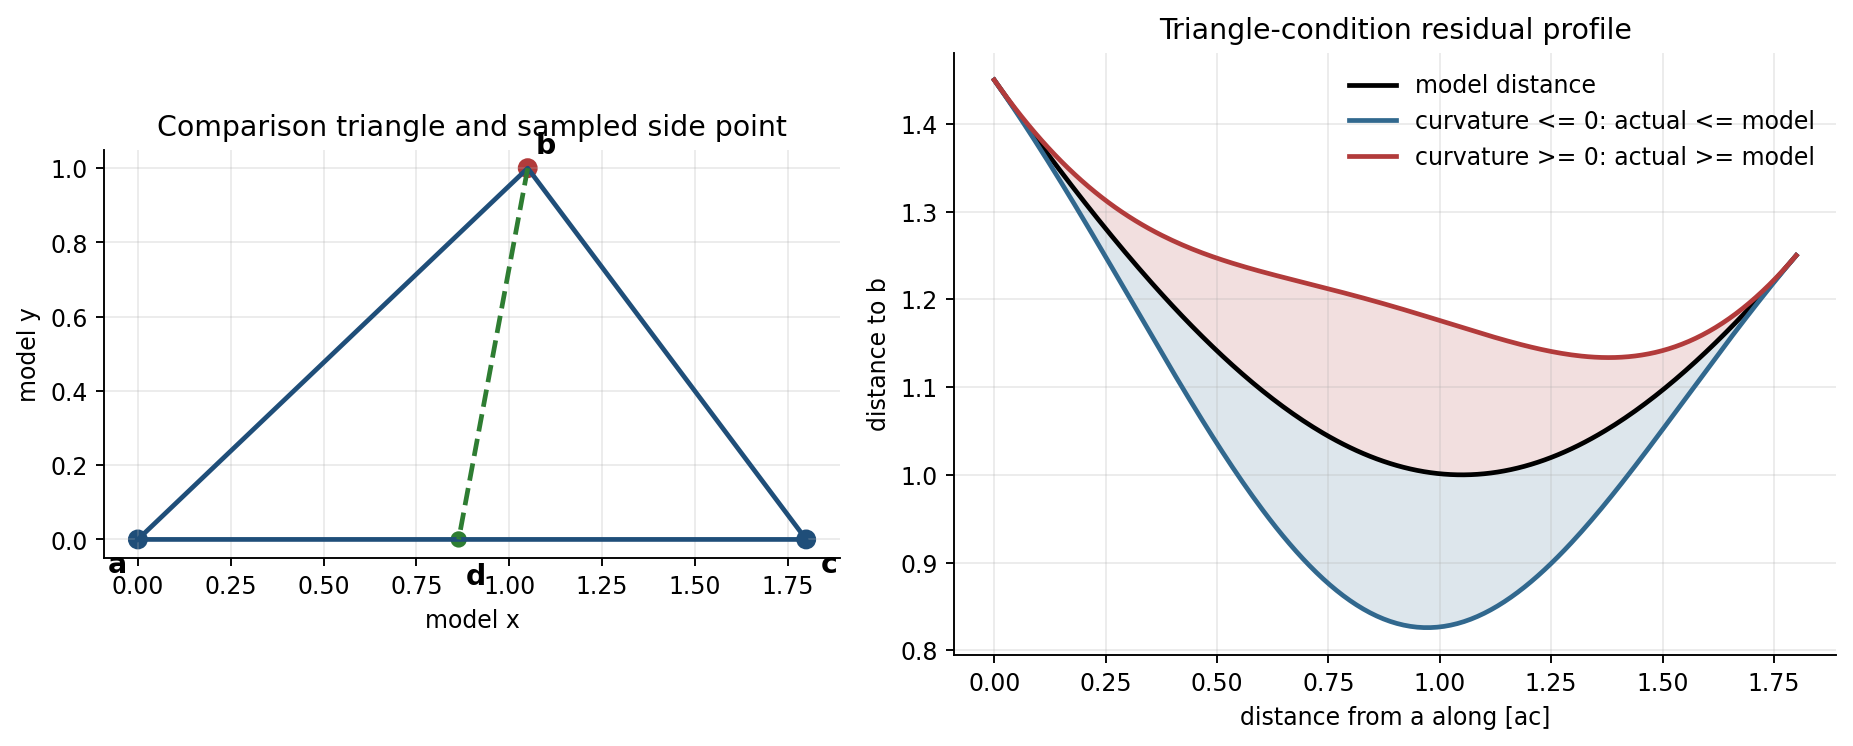

In [3]:
display_artifact(comparison_fig)

## First Examples: Fans Behave Better Than the L1 Plane

The chapter quickly warns that the comparison definition is stricter than just having many geodesics or a familiar topology. A finite fan of rays is CAT(0): the model triangle is always at least as thick as the tripod-like triangle. The L1 plane, despite being a perfectly good normed vector space, fails both signs of Alexandrov comparison. The two diagnostics below are small enough to read directly.


In [4]:
def l1_distance(P, Q=(0.0, 0.0)):
    return float(np.abs(np.asarray(P) - np.asarray(Q)).sum())

t = np.linspace(-1.0, 1.0, 201)
path1 = np.column_stack(((1 - t) / 2, (1 + t) / 2))
g1_actual = np.array([l1_distance(P) for P in path1])
g1_model = np.abs(t)
upper_violation = float(np.max(g1_actual - g1_model))

u = np.linspace(0.0, 1.0, 201)
path2 = np.column_stack((np.full_like(u, 0.5), 0.5 - u))
g2_actual = np.array([l1_distance(P) for P in path2])
g2_model = np.sqrt(1.0 - (u - 0.5) ** 2)
lower_violation = float(np.max(g2_model - g2_actual))

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
axes[0].plot(t, g1_actual, color='#b23b3b', lw=2, label='actual L1 distance')
axes[0].plot(t, g1_model, color='black', lw=2, label='Euclidean comparison')
axes[0].fill_between(t, g1_model, g1_actual, color='#b23b3b', alpha=0.15)
axes[0].set_title('L1 failure of curvature <= 0'); axes[0].set_xlabel('path parameter'); axes[0].set_ylabel('distance to origin'); axes[0].legend(frameon=False)
axes[1].plot(u, g2_actual, color='#31688e', lw=2, label='actual L1 distance')
axes[1].plot(u, g2_model, color='black', lw=2, label='Euclidean comparison')
axes[1].fill_between(u, g2_actual, g2_model, color='#31688e', alpha=0.15)
axes[1].set_title('L1 failure of curvature >= 0'); axes[1].set_xlabel('path parameter'); axes[1].legend(frameon=False)
fig.tight_layout()
examples_fig = save_matplotlib(fig, FIG_DIR / 'l1-normed-space-failures.png')
example_df = pd.DataFrame([
    {'space': 'three-ray fan R(3)', 'test': 'curvature <= 0', 'diagnostic': 0.0, 'outcome': 'passes locally by tripod thinness'},
    {'space': 'L1 plane', 'test': 'curvature <= 0', 'diagnostic': upper_violation, 'outcome': 'fails: actual distance rises above model'},
    {'space': 'L1 plane', 'test': 'curvature >= 0', 'diagnostic': lower_violation, 'outcome': 'fails: actual distance falls below model'},
])
examples_csv = save_csv(example_df, TABLE_DIR / 'example-diagnostics.csv')
examples_json = save_json({'source_sections': ['4.1 Definitions', '4.2 Examples'], 'l1_upper_violation': upper_violation, 'l1_lower_violation': lower_violation, 'fan_upper_residual_bound': 0.0}, CHECK_DIR / 'example-diagnostics.json')
example_df


,space,test,diagnostic,outcome
0,three-ray fan R(3),curvature <= 0,0.0,passes locally by tripod thinness
1,L1 plane,curvature <= 0,1.0,fails: actual distance rises above model
2,L1 plane,curvature >= 0,0.5,fails: actual distance falls below model


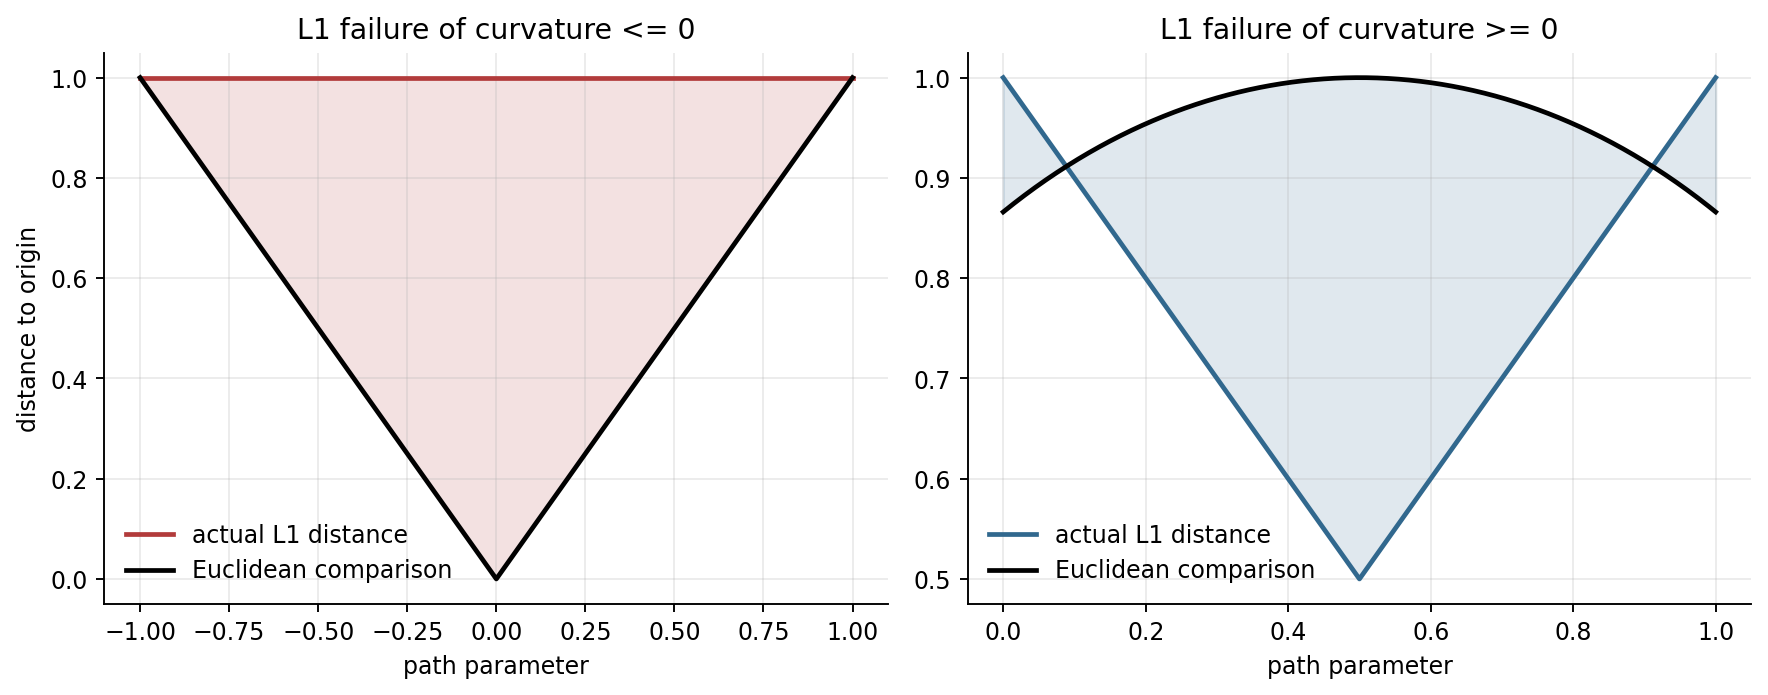

In [5]:
display_artifact(examples_fig)

## Angles and Equivalent Definitions

The chapter's several definitions are not separate theories. Distance comparison and triangle comparison are essentially the same data written in two coordinate systems. Angle comparison and hinge monotonicity need more work: comparison angles must have limits, and Alexandrov's lemma explains why opening a planar hinge changes the relevant diagonal in the right direction.

The graph below is a proof-route visual. It records which ideas feed which later tools: first variation depends on angle existence and semicontinuity, while the cone theorem depends on passing comparison through the cone distance formula.


In [6]:
proof_graph = nx.DiGraph()
proof_edges = [
    ('distance condition', 'triangle condition', 'same comparison segment sampled as side point'),
    ('triangle condition', 'angle condition', 'Alexandrov lemma turns diagonal inequalities into angle inequalities'),
    ('angle condition', 'monotonicity condition', 'hinge comparison angles move one way along geodesics'),
    ('monotonicity condition', 'angle exists', 'monotone bounded comparison angles have limits'),
    ('angle exists', 'semicontinuity of angles', 'limits of geodesics control limiting angles'),
    ('semicontinuity of angles', 'first variation', 'controls limiting shortest paths to a moving endpoint'),
    ('distance condition', 'distance-function analysis', 'one-dimensional restrictions are E-convex or E-concave'),
    ('triangle condition', 'k-plane definitions', 'replace Euclidean model with constant curvature k model'),
    ('k-plane definitions', 'globalization questions', 'ask when local normal regions become the whole space'),
    ('k-plane definitions', 'cone curvature theorem', 'base curvature +/-1 becomes cone curvature +/-0 away from vertex'),
    ('cone distance formula', 'cone curvature theorem', 'distances increase with the base angle in the cone law'),
]
for u_node, v_node, label in proof_edges:
    proof_graph.add_edge(u_node, v_node, label=label)
pos = nx.spring_layout(proof_graph, seed=12, k=1.6)
fig, ax = plt.subplots(figsize=(11.5, 7.0))
nx.draw_networkx_edges(proof_graph, pos, ax=ax, arrows=True, arrowstyle='-|>', arrowsize=14, width=1.5, edge_color='#5b6770')
nx.draw_networkx_nodes(proof_graph, pos, ax=ax, node_color='#f7f3e8', edgecolors='#263238', linewidths=1.2, node_size=2300)
nx.draw_networkx_labels(proof_graph, pos, ax=ax, font_size=8)
nx.draw_networkx_edge_labels(proof_graph, pos, edge_labels={(u, v): data['label'].split(' ')[0] + ' ...' for u, v, data in proof_graph.edges(data=True)}, ax=ax, font_size=7, rotate=False, label_pos=0.55)
ax.set_title('Proof route through Chapter 4 comparison definitions'); ax.axis('off')
proof_fig = save_matplotlib(fig, FIG_DIR / 'proof-route-equivalence-graph.png')
proof_json = save_json({'source_sections': ['4.3 Angles in Alexandrov Spaces and Equivalence of Definitions', '4.5 The First Variation Formula', '4.7 Curvature of Cones'], 'nodes': list(proof_graph.nodes()), 'edges': [{'from': u, 'to': v, 'role': data['label']} for u, v, data in proof_graph.edges(data=True)], 'check': {'node_count': proof_graph.number_of_nodes(), 'edge_count': proof_graph.number_of_edges(), 'acyclic': nx.is_directed_acyclic_graph(proof_graph)}}, CHECK_DIR / 'proof-route-equivalence-graph.json')
proof_fig, proof_json


(WindowsPath('D:/Geometry/A-Course-in-Metric-Geometry/artifacts/chapter-04/figures/proof-route-equivalence-graph.png'),
 WindowsPath('D:/Geometry/A-Course-in-Metric-Geometry/artifacts/chapter-04/checks/proof-route-equivalence-graph.json'))

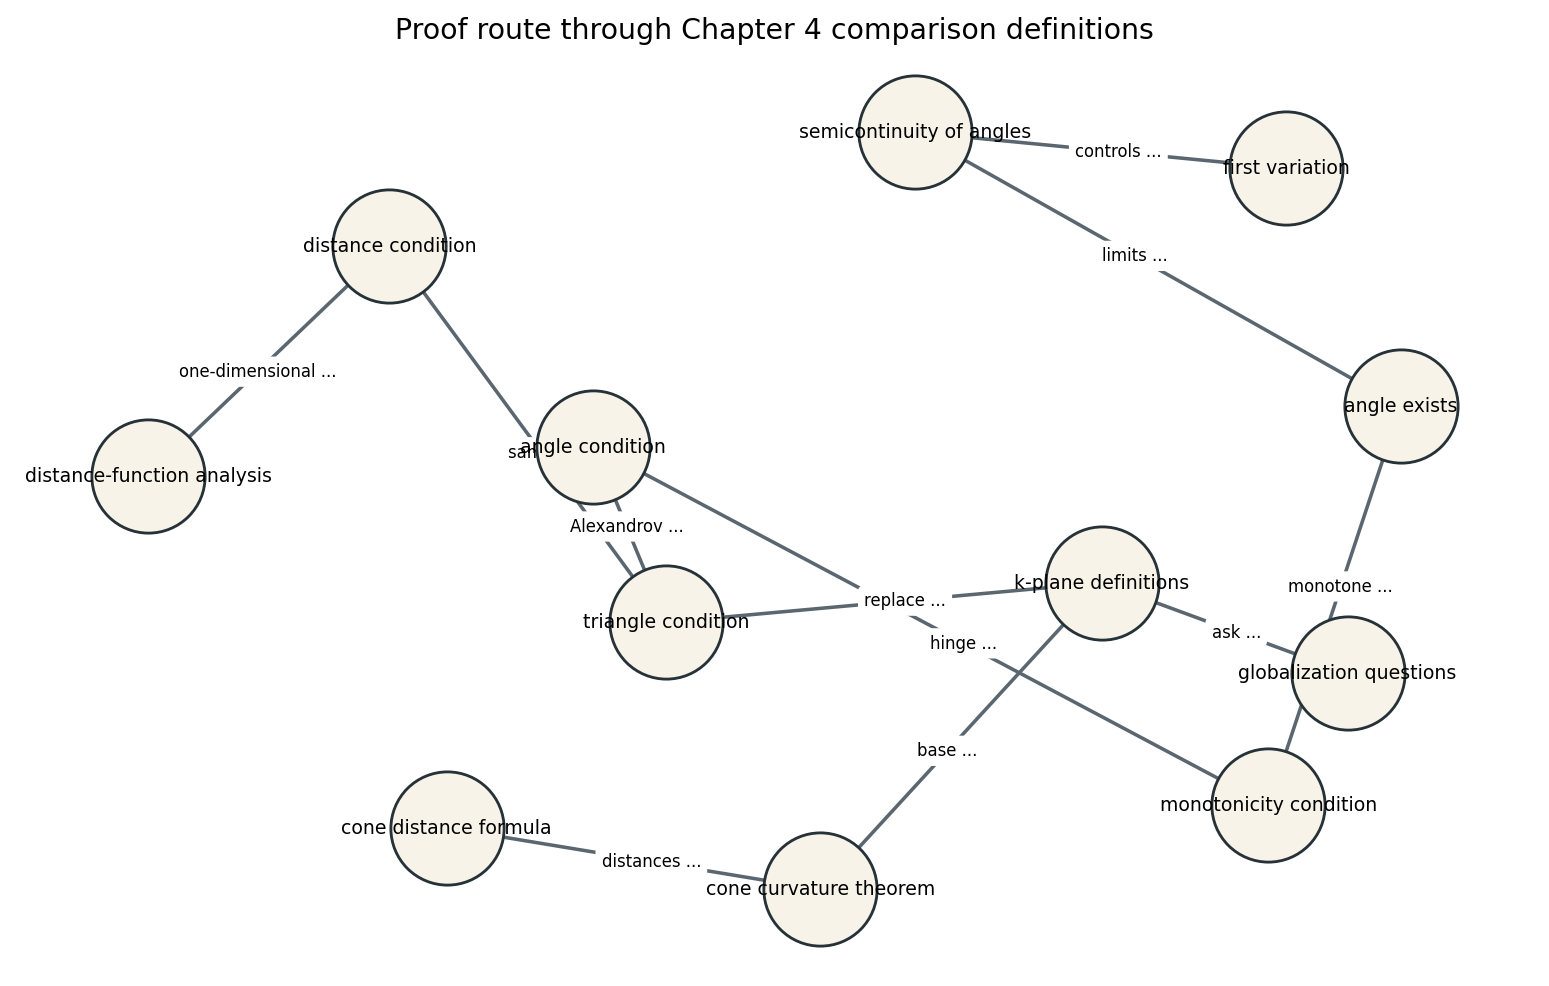

In [7]:
display_artifact(proof_fig)

## Distance-Function Analysis

A Euclidean distance function restricted to a line has the form `f(t) = sqrt((t+c)^2 + h^2)`. The chapter packages Alexandrov comparison as a convexity or concavity statement relative to this family `E`. A useful invariant is the differential residual `R(g) = g'' g - (1 - (g')^2)`. For an exact Euclidean comparison function the residual is zero.


In [8]:
t_sym, c_sym, h_sym = sp.symbols('t c h', positive=True)
f_sym = sp.sqrt((t_sym + c_sym)**2 + h_sym**2)
E_residual_symbolic = sp.simplify(sp.diff(f_sym, t_sym, 2) * f_sym - (1 - sp.diff(f_sym, t_sym)**2))
assert E_residual_symbolic == 0

def residual_numeric(values, x):
    first = np.gradient(values, x); second = np.gradient(first, x)
    return second * values - (1 - first**2)

x = np.linspace(-1.1, 1.1, 500)
base = np.sqrt((x + 0.25) ** 2 + 0.85 ** 2)
bubble = (1 - (x / 1.1) ** 2) ** 2
upper_like, lower_like = base - 0.045 * bubble, base + 0.045 * bubble
res_base, res_upper, res_lower = residual_numeric(base, x), residual_numeric(upper_like, x), residual_numeric(lower_like, x)
trim = slice(8, -8)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
axes[0].plot(x, base, color='black', lw=2, label='Euclidean E model')
axes[0].plot(x, upper_like, color='#31688e', lw=2, label='below model chord')
axes[0].plot(x, lower_like, color='#b23b3b', lw=2, label='above model chord')
axes[0].set_title('One-dimensional distance functions'); axes[0].set_xlabel('geodesic parameter t'); axes[0].set_ylabel('distance to reference point'); axes[0].legend(frameon=False)
axes[1].plot(x[trim], res_upper[trim], color='#31688e', lw=2, label='residual below model')
axes[1].plot(x[trim], res_lower[trim], color='#b23b3b', lw=2, label='residual above model')
axes[1].axhline(0, color='black', lw=1)
axes[1].set_title('Differential residual R(g)'); axes[1].set_xlabel('geodesic parameter t'); axes[1].set_ylabel("g''g - (1 - (g')^2)"); axes[1].legend(frameon=False)
fig.tight_layout()
distance_fig = save_matplotlib(fig, FIG_DIR / 'distance-function-analysis.png')
distance_json = save_json({'source_sections': ['4.4 Analysis of Distance Functions'], 'symbolic_E_residual': str(E_residual_symbolic), 'base_residual_abs_max_inner': float(np.max(np.abs(res_base[trim]))), 'upper_like_residual_median': float(np.median(res_upper[trim])), 'lower_like_residual_median': float(np.median(res_lower[trim])), 'nonexpanding_base_max_slope': float(np.max(np.abs(np.gradient(base, x))))}, CHECK_DIR / 'distance-function-analysis.json')
distance_fig, distance_json


(WindowsPath('D:/Geometry/A-Course-in-Metric-Geometry/artifacts/chapter-04/figures/distance-function-analysis.png'),
 WindowsPath('D:/Geometry/A-Course-in-Metric-Geometry/artifacts/chapter-04/checks/distance-function-analysis.json'))

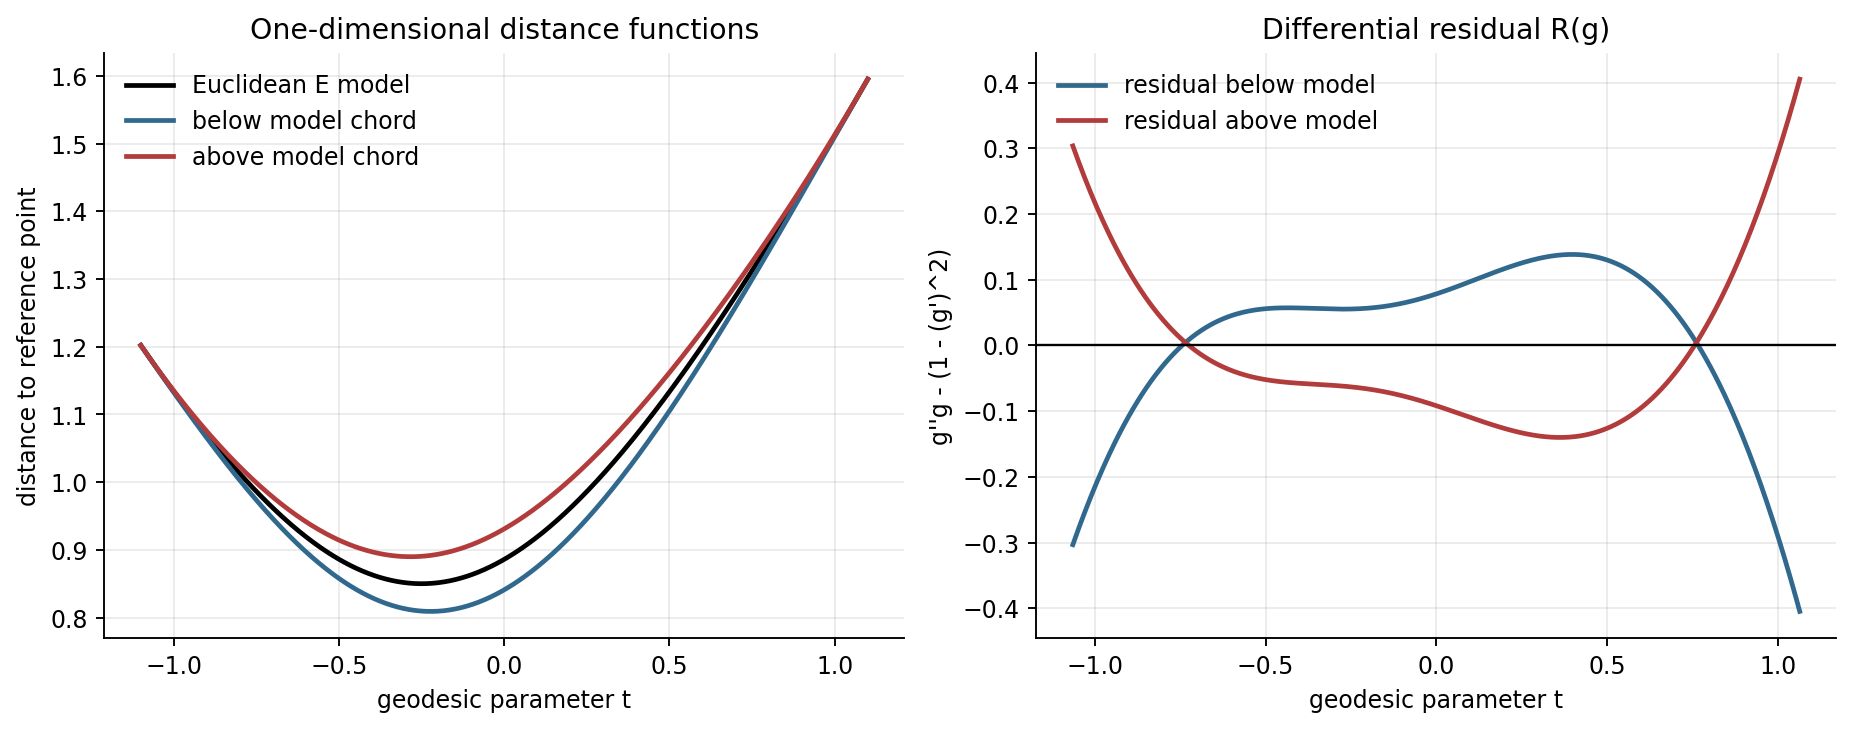

In [9]:
display_artifact(distance_fig)

## First Variation: Distance Differentiates by an Angle

The first variation theorem says that if one endpoint moves along a geodesic and a limiting shortest path to the fixed endpoint is known, then the one-sided derivative of the distance is `-cos(alpha)`, where `alpha` is the angle between the direction of motion and that limiting shortest path. In Alexandrov spaces it is a theorem because angles and limiting shortest paths need comparison geometry to behave well.


In [10]:
a0 = np.array([0.0, 0.0]); v = np.array([1.0, 0.0]); p = np.array([-0.35, 1.10])
w = p - a0
alpha = math.acos(np.dot(v, w) / np.linalg.norm(w))
target_derivative = -math.cos(alpha)
steps = np.logspace(-5, -0.2, 90)
l0 = np.linalg.norm(p - a0)
finite_difference = np.array([(np.linalg.norm(p - (a0 + h * v)) - l0) / h for h in steps])
variation_residual = finite_difference - target_derivative
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
axes[0].scatter([a0[0], p[0]], [a0[1], p[1]], s=60, color=['#31688e', '#b23b3b'])
axes[0].arrow(a0[0], a0[1], 0.8, 0.0, head_width=0.04, length_includes_head=True, color='#31688e')
axes[0].plot([a0[0], p[0]], [a0[1], p[1]], '--', color='#5b6770')
axes[0].text(a0[0]+0.03, a0[1]-0.08, 'moving endpoint a'); axes[0].text(p[0]+0.03, p[1]+0.03, 'fixed point p'); axes[0].text(0.15, 0.10, f'alpha = {alpha:.3f} rad')
axes[0].set_aspect('equal'); axes[0].set_title('Angle controlling the derivative'); axes[0].set_xlabel('x'); axes[0].set_ylabel('y')
axes[1].loglog(steps, np.abs(variation_residual), color='#6a4c93', lw=2); axes[1].invert_xaxis()
axes[1].set_title('Finite-difference residual'); axes[1].set_xlabel('step size'); axes[1].set_ylabel('|difference quotient + cos(alpha)|')
fig.tight_layout()
variation_fig = save_matplotlib(fig, FIG_DIR / 'first-variation-residual.png')
variation_json = save_json({'source_sections': ['4.5 The First Variation Formula'], 'alpha_radians': float(alpha), 'target_derivative': float(target_derivative), 'smallest_step_residual': float(abs(variation_residual[0])), 'largest_step_residual': float(abs(variation_residual[-1])), 'residual_decreases': bool(abs(variation_residual[0]) < abs(variation_residual[-1]))}, CHECK_DIR / 'first-variation-residual.json')
variation_fig, variation_json


(WindowsPath('D:/Geometry/A-Course-in-Metric-Geometry/artifacts/chapter-04/figures/first-variation-residual.png'),
 WindowsPath('D:/Geometry/A-Course-in-Metric-Geometry/artifacts/chapter-04/checks/first-variation-residual.json'))

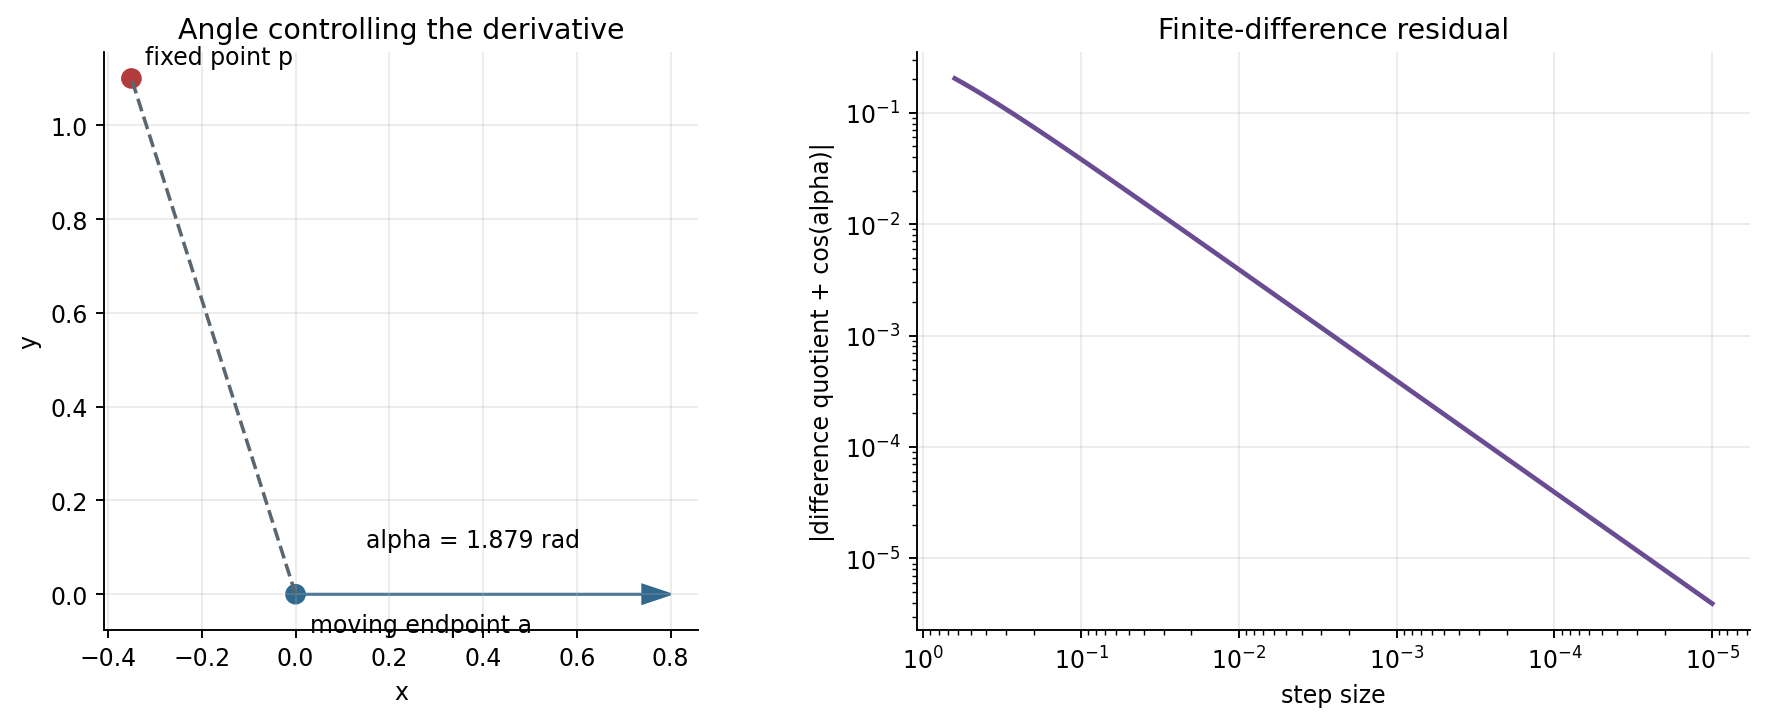

In [11]:
display_artifact(variation_fig)

## Nonzero Bounds and Globalization

For a nonzero bound `k`, the Euclidean plane is replaced by the simply connected surface of constant curvature `k`: a sphere of radius `1/sqrt(k)` when `k > 0`, the Euclidean plane when `k = 0`, and a hyperbolic plane when `k < 0`. The triangle inequality is not the only existence issue now. If `k > 0`, the model space has diameter `pi/sqrt(k)`, and comparison triangles are only available up to the corresponding perimeter and side-length restrictions.


In [12]:
def model_angle(adjacent_1, adjacent_2, opposite, k):
    if abs(k) < 1e-12:
        return comparison_angle(adjacent_1, adjacent_2, opposite)
    if k > 0:
        root = math.sqrt(k)
        numerator = math.cos(root * opposite) - math.cos(root * adjacent_1) * math.cos(root * adjacent_2)
        denominator = math.sin(root * adjacent_1) * math.sin(root * adjacent_2)
        return float(math.acos(np.clip(numerator / denominator, -1.0, 1.0)))
    root = math.sqrt(-k)
    numerator = math.cosh(root * adjacent_1) * math.cosh(root * adjacent_2) - math.cosh(root * opposite)
    denominator = math.sinh(root * adjacent_1) * math.sinh(root * adjacent_2)
    return float(math.acos(np.clip(numerator / denominator, -1.0, 1.0)))

def model_angle_sum(sides, k):
    ab, bc, ac = sides
    return sum([model_angle(ab, ac, bc, k), model_angle(ab, bc, ac, k), model_angle(ac, bc, ab, k)])

sides = (0.75, 0.82, 0.90)
k_values = np.linspace(-1.2, 1.2, 121)
angle_sums = np.array([model_angle_sum(sides, float(k)) for k in k_values])
rows = []
for k in [-1.0, 0.0, 1.0]:
    total = model_angle_sum(sides, k); Rk = math.inf if k <= 0 else math.pi / math.sqrt(k)
    rows.append({'k': k, 'model': 'hyperbolic' if k < 0 else ('Euclidean' if k == 0 else 'sphere'), 'angle_sum_radians': total, 'angle_sum_minus_pi': total - math.pi, 'R_k': Rk, 'perimeter_allowed_for_unique_small_triangle': math.inf if k <= 0 else 2 * Rk})
kplane_df = pd.DataFrame(rows)
kplane_csv = save_csv(kplane_df, TABLE_DIR / 'k-plane-angle-sums.csv')
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.plot(k_values, angle_sums - math.pi, color='#2e7d32', lw=2); ax.axhline(0, color='black', lw=1); ax.axvline(0, color='black', lw=1, alpha=0.5)
ax.set_title('Angle-sum residual for one small model triangle'); ax.set_xlabel('curvature bound k used by the model plane'); ax.set_ylabel('angle sum - pi')
kplane_fig = save_matplotlib(fig, FIG_DIR / 'k-plane-angle-sums.png')
kplane_json = save_json({'source_sections': ['4.6 Nonzero Curvature Bounds and Globalization'], 'side_lengths': sides, 'angle_sum_minus_pi_at_k_minus_1': float(kplane_df.loc[kplane_df['k'] == -1.0, 'angle_sum_minus_pi'].iloc[0]), 'angle_sum_minus_pi_at_k_0': float(kplane_df.loc[kplane_df['k'] == 0.0, 'angle_sum_minus_pi'].iloc[0]), 'angle_sum_minus_pi_at_k_1': float(kplane_df.loc[kplane_df['k'] == 1.0, 'angle_sum_minus_pi'].iloc[0]), 'globalization_notes': ['curvature <= k in the large means the whole connected space is a normal region', 'for k > 0, comparison triangles require side and perimeter restrictions', 'complete simply connected curvature <= k with k <= 0 globalizes later via the CAT theorem', 'complete curvature >= k globalizes later via Toponogov']}, CHECK_DIR / 'k-plane-angle-sums.json')
kplane_df


,k,model,angle_sum_radians,angle_sum_minus_pi,R_k,perimeter_allowed_for_unique_small_triangle
0,-1.0,hyperbolic,2.875565,-2.660281e-01,inf,inf
1,0.0,Euclidean,3.141593,4.440892e-16,inf,inf
2,1.0,sphere,3.457246,3.156533e-01,3.141593,6.283185


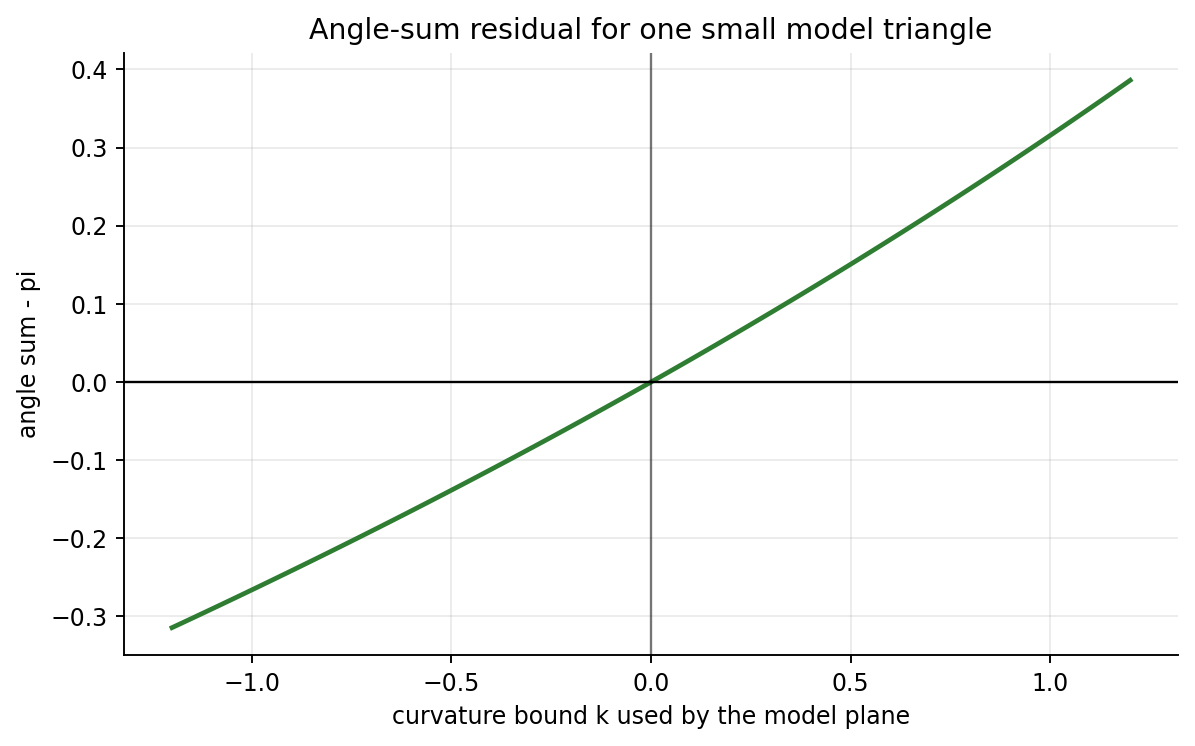

In [13]:
display_artifact(kplane_fig)

## Cone Curvature Lab

A metric cone over a circle is flat away from its vertex, so all the curvature information is concentrated in the total angle around the vertex. Total angle less than `2*pi` produces a positively curved cone, total angle equal to `2*pi` gives the plane, and total angle greater than `2*pi` produces the CAT(0) cone. This is the cleanest chapter example of a local curvature question near a point depending on global information in the link.

The more general cone theorem has the same shape: away from the vertex, curvature of the cone is controlled by whether the base has curvature bounded by `1`; at the vertex, global comparison in the base and perimeter restrictions decide what happens.


In [14]:
def cone_distance(r, s, base_distance):
    theta = min(float(base_distance), math.pi)
    return math.sqrt(max(r*r + s*s - 2*r*s*math.cos(theta), 0.0))

def cone_classification(total_angle):
    if abs(total_angle - 2 * math.pi) < 1e-10:
        return 'flat: both curvature <= 0 and >= 0'
    return 'curvature >= 0 at the vertex' if total_angle < 2 * math.pi else 'curvature <= 0 at the vertex'

angles = np.array([1.35 * math.pi, 2.0 * math.pi, 2.75 * math.pi])
cone_rows = [{'circle_length_total_angle': float(L), 'angle_defect_2pi_minus_L': float(2 * math.pi - L), 'classification': cone_classification(float(L)), 'sample_distance_same_radius_half_link': cone_distance(1.0, 1.0, L / 2)} for L in angles]
cone_df = pd.DataFrame(cone_rows)
cone_csv = save_csv(cone_df, TABLE_DIR / 'cone-curvature-classification.csv')
fig, axes = plt.subplots(1, 3, figsize=(12, 4.1), subplot_kw={'aspect': 'equal'})
for ax, L, color in zip(axes, angles, ['#b23b3b', '#404040', '#31688e']):
    theta = np.linspace(0, min(L, 2 * math.pi), 180)
    ax.plot([0, 1], [0, 0], color=color, lw=2); ax.plot(np.cos(theta), np.sin(theta), color=color, lw=2); ax.plot([0, np.cos(theta[-1])], [0, np.sin(theta[-1])], color=color, lw=2)
    if L < 2 * math.pi:
        ax.set_title(f'L = {L/math.pi:.2f} pi\npositive defect {(2*math.pi-L)/math.pi:.2f} pi')
    elif abs(L - 2 * math.pi) < 1e-10:
        ax.set_title('L = 2.00 pi\nflat plane')
    else:
        ax.set_title(f'L = {L/math.pi:.2f} pi\nexcess angle {(L-2*math.pi)/math.pi:.2f} pi')
        theta2 = np.linspace(2 * math.pi, L, 80); ax.plot(0.75*np.cos(theta2), 0.75*np.sin(theta2), '--', color=color, alpha=0.7)
    ax.scatter([0], [0], s=35, color='black'); ax.set_xlim(-1.15,1.15); ax.set_ylim(-1.15,1.15); ax.axis('off')
fig.suptitle('Unwrapped cone sectors: vertex curvature is total-angle bookkeeping', y=1.02)
cone_fig = save_matplotlib(fig, FIG_DIR / 'cone-curvature-lab.png')
cone_html = HTML_DIR / 'cone-angle-lab.html'
cone_html.write_text(r"""<!doctype html><html lang="en"><head><meta charset="utf-8"><title>Cone angle lab</title><style>body{font-family:system-ui,Segoe UI,sans-serif;margin:0;padding:18px;color:#172026;background:#fff}.wrap{max-width:820px;margin:auto}svg{width:100%;height:360px;border:1px solid #d7dde2;background:#fbfcfd}input{width:100%}.readout{font-weight:650;margin:10px 0 14px}</style></head><body><div class="wrap"><h2>Cone curvature lab</h2><div class="readout" id="readout"></div><input id="angle" type="range" min="0.8" max="3.4" step="0.01" value="2.0" aria-label="total angle in multiples of pi"><svg id="svg" viewBox="-140 -125 280 250"></svg></div><script>const svg=document.getElementById('svg'),slider=document.getElementById('angle'),readout=document.getElementById('readout');function polar(r,t){return[r*Math.cos(t),r*Math.sin(t)]}function draw(){const m=parseFloat(slider.value),L=m*Math.PI,c=Math.min(L,2*Math.PI),n=120,cls=Math.abs(m-2)<0.01?'flat: both signs':(m<2?'curvature >= 0 near vertex':'curvature <= 0 near vertex');readout.textContent=`total angle L = ${m.toFixed(2)} pi; angle defect 2pi-L = ${(2-m).toFixed(2)} pi; ${cls}`;let d=`M 0 0 L 105 0 `;for(let i=0;i<=n;i++){const p=polar(105,c*i/n);d+=`L ${p[0].toFixed(2)} ${p[1].toFixed(2)} `}d+=`L 0 0`;svg.innerHTML=`<path d="${d}" fill="#dfeef3" stroke="#24566b" stroke-width="2"/><circle cx="0" cy="0" r="4" fill="#111"/><text x="-132" y="-105" font-size="11">Move the slider: short links make fat cones, long links make CAT(0) cones.</text>`;if(L>2*Math.PI){let d2='';for(let i=0;i<=60;i++){const p=polar(82,2*Math.PI+(L-2*Math.PI)*i/60);d2+=(i?'L':'M')+` ${p[0].toFixed(2)} ${p[1].toFixed(2)} `}svg.innerHTML+=`<path d="${d2}" fill="none" stroke="#9b3d3d" stroke-width="2" stroke-dasharray="5 4"/>`;}}slider.addEventListener('input',draw);draw();</script></body></html>""", encoding='utf-8')
cone_json = save_json({'source_sections': ['4.1 Definitions', '4.2 Examples', '4.7 Curvature of Cones'], 'classifications': cone_rows, 'cone_distance_formula': 'sqrt(r^2+s^2-2rs cos(min(base_distance, pi)))', 'general_theorem_summary': {'away_from_vertex': 'Cone without vertex has curvature sign 0 exactly when base has corresponding curvature sign 1 locally.', 'curvature_le_0_at_vertex': 'Requires the base to have curvature <= 1 in the large, componentwise if disconnected.', 'curvature_ge_0_at_vertex': 'Requires a connected base with curvature >= 1 in the large and no triangle perimeter above 2pi, apart from the two-point line case.'}}, CHECK_DIR / 'cone-curvature-lab.json')
cone_df


,circle_length_total_angle,angle_defect_2pi_minus_L,classification,sample_distance_same_radius_half_link
0,4.241150,2.042035,curvature >= 0 at the vertex,1.744992
1,6.283185,0.000000,flat: both curvature <= 0 and >= 0,2.000000
2,8.639380,-2.356194,curvature <= 0 at the vertex,2.000000


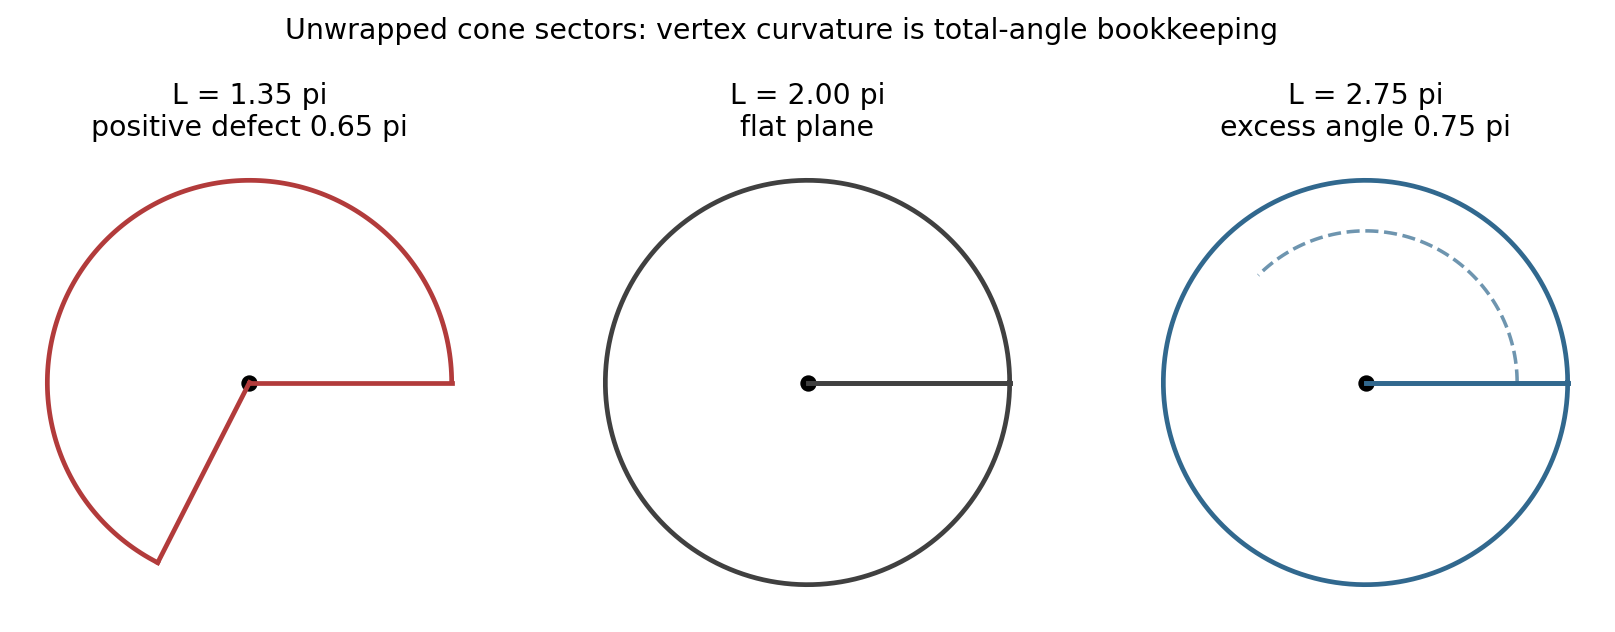

In [15]:
display_artifact(cone_fig)
display_artifact(cone_html)

## Source Coverage and Final Sanity Checks

The notebook closes by recording exactly which source sections are represented by which artifacts. This JSON is intentionally explicit: later QC can check that the chapter is not just executable, but that each major concept in the assigned span has a visual, numeric, symbolic, or tabular witness.


In [16]:
coverage = {
    'chapter': 'Chapter 4: Spaces of Bounded Curvature',
    'source_span': SOURCE_SPAN,
    'pdf_used_for': 'structure, terminology, theorem orientation, and coverage only',
    'sections': [
        {'section': '4.1 Definitions', 'covered_by': ['comparison-triangle-residuals.png', 'example-diagnostics.csv'], 'concepts': ['distance condition', 'triangle condition', 'angle condition', 'comparison triangle']},
        {'section': '4.2 Examples', 'covered_by': ['example-diagnostics.csv', 'cone-curvature-lab.png'], 'concepts': ['fans and graphs', 'metric bouquet', 'polyhedral links', 'normed-space failure']},
        {'section': '4.3 Angles and equivalence', 'covered_by': ['proof-route-equivalence-graph.png'], 'concepts': ['monotonicity of comparison angles', 'Alexandrov lemma', 'angle existence', 'semicontinuity']},
        {'section': '4.4 Analysis of distance functions', 'covered_by': ['distance-function-analysis.png'], 'concepts': ['E-convexity', 'E-concavity', 'nonexpanding distance restrictions', 'differential residual']},
        {'section': '4.5 First variation', 'covered_by': ['first-variation-residual.png'], 'concepts': ['one-sided derivative', 'angle to limiting shortest path', 'minimum angle']},
        {'section': '4.6 Nonzero bounds and globalization', 'covered_by': ['k-plane-angle-sums.png', 'k-plane-angle-sums.csv'], 'concepts': ['k-plane', 'positive-curvature diameter threshold', 'global normal region', 'globalization theorems']},
        {'section': '4.7 Curvature of cones', 'covered_by': ['cone-curvature-lab.png', 'cone-angle-lab.html', 'cone-curvature-classification.csv'], 'concepts': ['cone over a circle', 'base curvature +/-1', 'vertex depends on global base', 'perimeter obstruction']},
    ],
    'library_routing': {'numpy': 'finite comparison residuals and numerical derivatives', 'matplotlib': 'durable static diagrams for local comparison geometry', 'sympy': 'exact check that Euclidean distance functions have zero E-residual', 'networkx': 'proof-route dependency graph for equivalent definitions', 'pandas': 'coverage and diagnostic tables', 'html-js': 'dependency-light interactive cone total-angle lab'}
}
coverage_json = save_json(coverage, CHECK_DIR / 'source-coverage.json')
coverage_csv = save_csv(pd.DataFrame(coverage['sections']), TABLE_DIR / 'source-coverage.csv')
artifact_paths = [comparison_fig, examples_fig, proof_fig, distance_fig, variation_fig, kplane_fig, cone_fig, cone_html, examples_csv, kplane_csv, cone_csv, coverage_csv, comparison_json, examples_json, proof_json, distance_json, variation_json, kplane_json, cone_json, coverage_json]
artifact_records = [{'path': rel(path), 'exists': Path(path).exists(), 'bytes': Path(path).stat().st_size if Path(path).exists() else 0} for path in artifact_paths]
final_sanity = {
    'source_span': SOURCE_SPAN,
    'standalone_contract': True,
    'pdf_used_for': coverage['pdf_used_for'],
    'artifacts': artifact_records,
    'topic_checks': {
        'comparison_upper_residual_max_nonpositive': comparison_checks['thin_residual_max'] <= 1e-12,
        'comparison_lower_residual_min_nonnegative': comparison_checks['fat_residual_min'] >= -1e-12,
        'l1_plane_fails_upper': upper_violation > 0.9,
        'l1_plane_fails_lower': lower_violation > 0.35,
        'symbolic_E_residual_zero': str(E_residual_symbolic) == '0',
        'first_variation_residual_decreases': bool(abs(variation_residual[0]) < abs(variation_residual[-1])),
        'k_angle_sum_order': bool(kplane_df.loc[0, 'angle_sum_minus_pi'] < kplane_df.loc[1, 'angle_sum_minus_pi'] < kplane_df.loc[2, 'angle_sum_minus_pi']),
        'cone_short_positive_defect': bool(cone_df.iloc[0]['angle_defect_2pi_minus_L'] > 0),
        'cone_long_negative_defect': bool(cone_df.iloc[2]['angle_defect_2pi_minus_L'] < 0),
        'proof_graph_acyclic': nx.is_directed_acyclic_graph(proof_graph),
        'coverage_sections': len(coverage['sections']),
    }
}
final_json = save_json(final_sanity, CHECK_DIR / 'final-sanity.json')
assert len(coverage['sections']) == 7
assert all(item['exists'] and item['bytes'] > 100 for item in artifact_records)
assert all(value if isinstance(value, bool) else True for value in final_sanity['topic_checks'].values())
pd.DataFrame(artifact_records)


,path,exists,bytes
0,artifacts/chapter-04/figures/comparison-triang...,True,138977
1,artifacts/chapter-04/figures/l1-normed-space-f...,True,99743
2,artifacts/chapter-04/figures/proof-route-equiv...,True,160440
3,artifacts/chapter-04/figures/distance-function...,True,143069
4,artifacts/chapter-04/figures/first-variation-r...,True,85864
5,artifacts/chapter-04/figures/k-plane-angle-sum...,True,52018
6,artifacts/chapter-04/figures/cone-curvature-la...,True,84209
7,artifacts/chapter-04/html/cone-angle-lab.html,True,1833
8,artifacts/chapter-04/tables/example-diagnostic...,True,244
9,artifacts/chapter-04/tables/k-plane-angle-sums...,True,306


## Takeaways

Alexandrov curvature bounds are comparison rules, not pointwise curvature formulas. The same local triangle can be inspected through distance functions, side-point distances, hinge angles, or monotonicity of comparison angles. The definitions are equivalent because planar comparison geometry controls how diagonals and angles respond when a hinge is opened.

Upper and lower bounds point in opposite metric directions. Curvature `<= 0` makes triangles thin relative to the model; curvature `>= 0` makes them fat. The L1 plane is the useful warning example: a normed space can be geodesic and homogeneous while failing both Alexandrov signs.

The analytic view says that distance-to-a-point functions along geodesics are constrained by the Euclidean family `sqrt((t+c)^2+h^2)`. The first variation theorem turns this constraint into a derivative formula governed by an angle. Nonzero bounds keep the same comparison logic but swap the model plane for a `k`-plane, which is why global restrictions appear when `k > 0`. Finally, cones show how local curvature at a vertex can encode global information in the link: short links make positive defect, long links make CAT(0) excess, and the general theorem formalizes that bookkeeping for arbitrary bases.
